# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


In [0]:
import tensorflow as tf

### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [32]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170500096/170498071 [==============================] - 9s 0us/step


Label: [9]


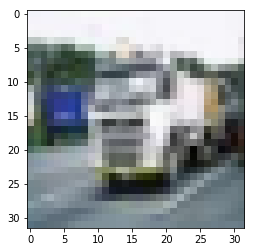

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[1000]))
plt.imshow(x_train[1000], cmap='gray')

In [0]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train  /= 255
x_test /= 255

In [0]:
y_train= y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [36]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, MaxPooling2D
from keras.utils import np_utils
from keras import backend as K



Using TensorFlow backend.


In [0]:
X_train_lt5 = x_train[y_train < 5] 
y_train_lt5 = y_train[y_train < 5]
X_test_lt5 = x_test[y_test < 5]
y_test_lt5 = y_test[y_test < 5]

X_train_gte5 = x_train[y_train >= 5] 
y_train_gte5 = y_train[y_train >= 5] -5
X_test_gte5 = x_test[y_test >= 5]
y_test_gte5 = y_test[y_test >= 5] -5 

In [0]:
def print_x_y():
  print("x_train_lt5 shape:",X_train_lt5.shape)
  print("y_train_lt5 shape:",y_train_lt5.shape)
  print("X_test_lt5 shape:",X_test_lt5.shape)
  print("y_test_lt5 shape:",y_test_lt5.shape)
  print("X_train_gte5 shape:",X_train_gte5.shape)
  print("y_train_gte5 shape:",y_train_gte5.shape)
  print("X_test_gte5 shape:",X_test_gte5.shape)
  print("y_test_gte5 shape:",y_test_gte5.shape)

In [39]:
print_x_y()


x_train_lt5 shape: (25000, 32, 32, 3)
y_train_lt5 shape: (25000,)
X_test_lt5 shape: (5000, 32, 32, 3)
y_test_lt5 shape: (5000,)
X_train_gte5 shape: (25000, 32, 32, 3)
y_train_gte5 shape: (25000,)
X_test_gte5 shape: (5000, 32, 32, 3)
y_test_gte5 shape: (5000,)


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
y_train_lt5_classes = np_utils.to_categorical(y_train_lt5, 5) # 5 we are passing as number of category
y_test_lt5_classes = np_utils.to_categorical(y_test_lt5, 5) # 5 we are passing as number of category

In [41]:
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras import regularizers

y_test_lt5_classes

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.]], dtype=float32)

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [42]:
 weight_decay = 1e-4
# create  model
model = Sequential()
model.add(Convolution2D(128,3,3,activation='relu', input_shape = (32,32,3)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
 
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
 
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))
 
model.add(Flatten())
model.add(Dense(5, activation='softmax'))
 

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='sgd')
model.fit(X_train_lt5, y_train_lt5_classes,
              batch_size=128, nb_epoch=30,
              verbose=1,
              validation_data=(X_test_lt5, y_test_lt5_classes))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (3, 3), activation="relu", input_shape=(32, 32, 3...)`
  after removing the cwd from sys.path.




Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:39: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 25000 samples, validate on 5000 samples
Epoch 1/30
25000/25000 [==============================] - 11s 428us/step - loss: 1.5650 - acc: 0.5051 - val_loss: 1.0983 - val_acc: 0.6126
Epoch 2/30
25000/25000 [==============================] - 6s 242us/step - loss: 1.1345 - acc: 0.5957 - val_loss: 1.3785 - val_acc: 0.5528
Epoch 3/30
25000/25000 [==============================] - 6s 242us/step - loss: 0.9809 - acc: 0.6398 - val_loss: 1.2586 - val_acc: 0.5806
Epoch 4/30
25000/25000 [==============================] - 6s 243us/step - loss: 0.8896 - acc: 0.6708 - val_loss: 1.9093 - val_acc: 0.4494
Epoch 5/30
25000/25000 [==============================] - 6s 242us/step - loss: 0.8381 - acc: 0.6934 - val_loss: 0.9342 - val_acc: 0.6674
Epoch 6/30
25000/25000 [==============================] - 6s 244us/step - loss: 0.7889 - acc: 0.7083 - val_loss: 0.8466 - val_acc: 0.6892
Epoch 7/30
25000/25000 [==============================] - 6s 244us/step - loss: 0.7661 - acc: 0.7224 - val_loss: 0.7718 - 

In [43]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 30, 30, 128)       3584      
_________________________________________________________________
activation_1 (Activation)    (None, 30, 30, 128)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 30, 30, 128)       512       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 30, 30, 32)        36896     
_________________________________________________________________
activation_2 (Activation)    (None, 30, 30, 32)        0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 30, 30, 32)        128       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 15, 15, 32)       

### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [0]:
#Set pre-trained model layers to not trainable

#for layer in model.layers:
#   layer.trainable = False

#Set pre-trained model first layer to not trainable
model.layers[0].trainable = False
model.layers[3].trainable = False
model.layers[8].trainable = False
model.layers[11].trainable = False
model.layers[16].trainable = False
model.layers[19].trainable = False

### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [45]:
y_train_gte5_classes = np_utils.to_categorical(y_train_gte5, 5) # 5 we are passing as number of category
y_test_gte5_classes = np_utils.to_categorical(y_test_gte5, 5) # 5 we are passing as number of category
y_train_gte5_classes[0:5]

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.]], dtype=float32)

In [46]:

model.fit(X_train_gte5, y_train_gte5_classes,
              batch_size=128, nb_epoch=10,
              verbose=1,
              validation_data=(X_test_gte5, y_test_gte5_classes))

Train on 25000 samples, validate on 5000 samples
Epoch 1/10
  640/25000 [..............................] - ETA: 5s - loss: 3.0057 - acc: 0.3063

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """
/usr/local/lib/python3.6/dist-packages/keras/engine/training.py:493: UserWarning: Discrepancy between trainable weights and collected trainable weights, did you set `model.trainable` without calling `model.compile` after ?
  'Discrepancy between trainable weights and collected trainable'


25000/25000 [==============================] - 6s 249us/step - loss: 0.7703 - acc: 0.7458 - val_loss: 0.5179 - val_acc: 0.8218
Epoch 2/10
25000/25000 [==============================] - 6s 249us/step - loss: 0.5103 - acc: 0.8281 - val_loss: 0.4495 - val_acc: 0.8470
Epoch 3/10
25000/25000 [==============================] - 6s 248us/step - loss: 0.4579 - acc: 0.8477 - val_loss: 0.5304 - val_acc: 0.8274
Epoch 4/10
25000/25000 [==============================] - 6s 253us/step - loss: 0.4257 - acc: 0.8558 - val_loss: 0.5799 - val_acc: 0.8214
Epoch 5/10
25000/25000 [==============================] - 6s 251us/step - loss: 0.4016 - acc: 0.8673 - val_loss: 0.5052 - val_acc: 0.8320
Epoch 6/10
25000/25000 [==============================] - 6s 249us/step - loss: 0.3886 - acc: 0.8727 - val_loss: 0.4210 - val_acc: 0.8614
Epoch 7/10
25000/25000 [==============================] - 6s 250us/step - loss: 0.3753 - acc: 0.8770 - val_loss: 0.4015 - val_acc: 0.8696
Epoch 8/10
25000/25000 [=====================

In [47]:
score = model.evaluate(X_test_gte5, y_test_gte5_classes, verbose=0)
print('Test accuracy:', score[1])


Test accuracy: 0.8466


# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [0]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [52]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [53]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [54]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [55]:
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# TfidfVectorizer
vect = TfidfVectorizer()
vectors = vect.fit_transform(twenty_train.data)
vectors.nnz / float(vectors.shape[0])

162.1116526362428

In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics 
vectors_test = vect.transform(twenty_test.data)
clf = MultinomialNB(alpha=.01)
clf.fit(vectors, twenty_train.target)
pred = clf.predict(vectors_test)

def show_top10(classifier, vectorizer, categories):
    feature_names = np.asarray(vectorizer.get_feature_names())
    for i, category in enumerate(categories):
        top10 = np.argsort(classifier.coef_[i])[-10:]
        print("%s: %s" % (category, " ".join(feature_names[top10])))

show_top10(clf, vect, twenty_train.target_names)
show_top10(clf, vect, twenty_test.target_names)

alt.atheism: edu it and in you that is of to the
comp.graphics: edu in it is for graphics and of to the
sci.med: pitt edu that it in and is to of the
soc.religion.christian: you it god in is and that to of the
alt.atheism: edu it and in you that is of to the
comp.graphics: edu in it is for graphics and of to the
sci.med: pitt edu that it in and is to of the
soc.religion.christian: you it god in is and that to of the


### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [57]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(vectors, twenty_train.target)
vectors_test = vect.transform(twenty_test.data)
pred = clf.predict(vectors_test)
metrics.f1_score(twenty_test.target, pred, average='macro')

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:469: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


0.8836373105379085